# Lý thuyết và Toán học về RNN

Notebook này đi sâu vào cơ chế kiến trúc, toán học hình thức và hành vi đạo hàm của Mạng Nơ-ron Hồi quy (RNNs).

Chúng ta sẽ sử dụng nghiêm ngặt các ký hiệu chuẩn trong học sâu ($W, U, V$):
- $W$: Ma trận trọng số từ đầu vào đến trạng thái ẩn ($x_t \to h_t$)
- $U$: Ma trận trọng số hồi quy giữa các trạng thái ẩn ($h_{t-1} \to h_t$)
- $V$: Ma trận trọng số từ trạng thái ẩn đến đầu ra ($h_t \to \hat{y}_t$)
- $b_h, b_y$: Các vector độ lệch (bias) cho trạng thái ẩn và đầu ra


## Cơ chế Kiến trúc

Mạng Nơ-ron Hồi quy được thiết kế để xử lý dữ liệu chuỗi. Khác với các mạng truyền thẳng tiêu chuẩn, RNN sở hữu một trạng thái nội bộ (bộ nhớ) để nắm bắt thông tin từ các đầu vào trước đó trong chuỗi.

### Trải dài theo Thời gian (Unrolling Through Time)
Một RNN có thể được hình dung như nhiều bản sao của cùng một mạng, mỗi mạng truyền một thông điệp cho mạng kế tiếp. Khi chúng ta "trải dài" một RNN qua một chuỗi có độ dài $T$, chúng ta tạo ra một đồ thị tính toán kéo dài qua $T$ bước thời gian.

### Chia sẻ Tham số
Đặc biệt quan trọng, các ma trận trọng số ($W, U, V$) và độ lệch ($b_h, b_y$) được chia sẻ giống hệt nhau qua tất cả các bước thời gian $t=1, \dots, T$. Sự chia sẻ tham số này cho phép mô hình tổng quát hóa qua các độ dài chuỗi khác nhau và giảm đáng kể số lượng tham số có thể học.


## Toán học Hình thức: Lan truyền Tiến (Forward Pass)

Tại mỗi bước thời gian $t$, RNN nhận một vector đầu vào $x_t$ và vector trạng thái ẩn trước đó $h_{t-1}$. 

Quá trình lan truyền tiến được định nghĩa bởi các phương trình vector sau:

1. **Cập nhật Trạng thái Ẩn**:
$$h_t = \tanh(U h_{t-1} + W x_t + b_h)$$

2. **Dự đoán Đầu ra**:
$$\hat{y}_t = V h_t + b_y$$

trong đó hàm $\tanh$ giới thiệu tính phi tuyến, giới hạn các giá trị của trạng thái ẩn trong khoảng $[-1, 1]$.


## Lan truyền Ngược qua Thời gian (BPTT)

Để huấn luyện một RNN, chúng ta phải tính toán đạo hàm của tổng hàm mất mát chuỗi $L = \sum_{t=1}^T L_t$ đối với các tham số được chia sẻ $U, W,$ và $V$. Vì các tham số được chia sẻ qua các bước thời gian, tổng đạo hàm là tổng của các đạo hàm tại từng bước thời gian riêng lẻ.

### Đạo hàm theo $U$ và $W$
Bằng cách áp dụng quy tắc chuỗi đa biến, việc đạo hàm cho $U$ và $W$ yêu cầu lan truyền ngược đạo hàm qua các trạng thái ẩn $h_k$ cho đến bước thời gian $t$:

$$\frac{\partial L}{\partial U} = \sum_{t=1}^T \sum_{k=1}^t \frac{\partial L_t}{\partial h_t} \frac{\partial h_t}{\partial h_k} \frac{\partial h_k}{\partial U}$$

$$\frac{\partial L}{\partial W} = \sum_{t=1}^T \sum_{k=1}^t \frac{\partial L_t}{\partial h_t} \frac{\partial h_t}{\partial h_k} \frac{\partial h_k}{\partial W}$$

### Đạo hàm theo $V$
Ma trận đầu ra $V$ chỉ ảnh hưởng đến đầu ra tại bước thời gian hiện tại $t$, do đó đạo hàm của nó không cần lan truyền ngược qua các trạng thái ẩn trước đó:

$$\frac{\partial L}{\partial V} = \sum_{t=1}^T \frac{\partial L_t}{\partial \hat{y}_t} h_t^T$$


## Triệt tiêu & Bùng nổ Đạo hàm (Vanishing & Exploding Gradients)

Vấn đề cơ bản trong BPTT phát sinh từ thành phần $\frac{\partial h_t}{\partial h_k}$, biểu thị cách một trạng thái ẩn trong quá khứ $h_k$ ảnh hưởng đến trạng thái ẩn trong tương lai $h_t$.

### Tích Jacobian Hồi quy
Sử dụng quy tắc chuỗi, thành phần này là tích của các ma trận Jacobian qua tất cả các bước trung gian:

$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^t \frac{\partial h_j}{\partial h_{j-1}} = \prod_{j=k+1}^t \text{diag}(1 - h_j^2) U^T$$

### Suy giảm Hàm mũ
Gọi $\lambda_i(U)$ là các giá trị riêng của $U$. Vì đạo hàm của hàm kích hoạt $\tanh$ bị chặn bởi 1 ($\tanh'(z) = 1 - \tanh^2(z) \le 1$):
- Nếu độ lớn giá trị riêng lớn nhất $\vert\lambda_i(U)\vert < 1$, tích của các ma trận Jacobian thu nhỏ theo cấp số nhân về 0 khi $(t-k)$ tăng lên. Đây là **Vấn đề Triệt tiêu Đạo hàm**, ngăn cản mạng học các phụ thuộc dài hạn.
- Ngược lại, nếu $\vert\lambda_i(U)\vert > 1$, đạo hàm có thể tăng trưởng theo cấp số nhân, gây ra **Bùng nổ Đạo hàm**.


## Sự Tiến hóa Kiến trúc

Để giải quyết vấn đề triệt tiêu đạo hàm, các kiến trúc với cơ chế cổng (gating) đã được giới thiệu, cung cấp các đường dẫn cộng (additive) để đạo hàm luân chuyển qua thời gian.

### Bộ nhớ Ngắn-Dài hạn (LSTM)
LSTM duy trì một trạng thái tế bào $c_t$ cùng với trạng thái ẩn $h_t$. Chúng sử dụng ba cổng để kiểm soát luồng thông tin:

1. **Cổng Quên (Forget Gate)**: $f_t = \sigma(U_f h_{t-1} + W_f x_t + b_f)$
2. **Cổng Đầu vào (Input Gate)**: $i_t = \sigma(U_i h_{t-1} + W_i x_t + b_i)$
3. **Tế bào Ứng viên (Candidate Cell)**: $\tilde{c}_t = \tanh(U_c h_{t-1} + W_c x_t + b_c)$
4. **Cập nhật Trạng thái Tế bào**: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$
5. **Cổng Đầu ra (Output Gate)**: $o_t = \sigma(U_o h_{t-1} + W_o x_t + b_o)$
6. **Trạng thái Ẩn**: $h_t = o_t \odot \tanh(c_t)$

### Đơn vị Hồi quy có Cổng (GRU)
GRU đơn giản hóa LSTM bằng cách hợp nhất trạng thái tế bào và trạng thái ẩn, chỉ sử dụng hai cổng:

1. **Cổng Thiết lập lại (Reset Gate)**: $r_t = \sigma(U_r h_{t-1} + W_r x_t + b_r)$
2. **Cổng Cập nhật (Update Gate)**: $z_t = \sigma(U_z h_{t-1} + W_z x_t + b_z)$
3. **Trạng thái Ẩn Ứng viên**: $\tilde{h}_t = \tanh(U_h (r_t \odot h_{t-1}) + W_h x_t + b_h)$
4. **Cập nhật Trạng thái Ẩn**: $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$


## Mã Kiểm chứng: Theo dõi Sự Suy giảm Đạo hàm

Chúng tôi cung cấp một triển khai PyTorch tối giản để kiểm chứng bằng thực nghiệm hiện tượng triệt tiêu đạo hàm. Chúng ta khởi tạo một ô Vanilla RNN cơ bản và theo dõi chuẩn (norm) của đạo hàm $\frac{\partial L_t}{\partial h_0}$ qua các độ dài chuỗi.


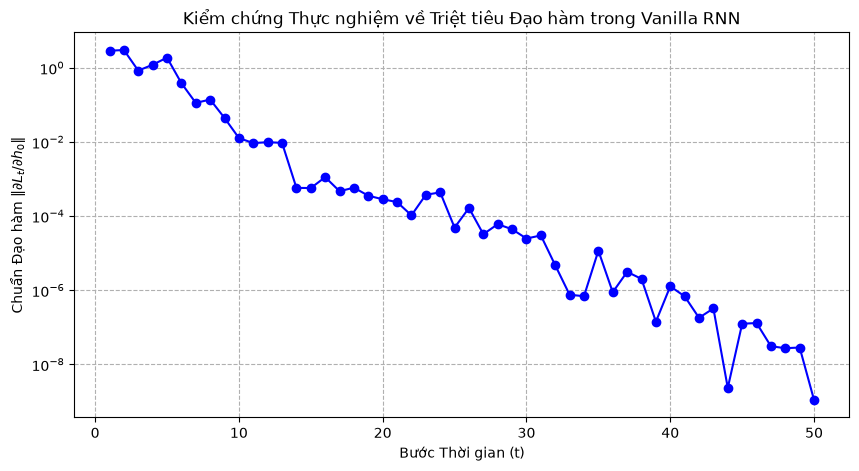

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Đặt seed để đảm bảo tính tái lập
torch.manual_seed(42)

def track_gradient_decay(seq_length=50, hidden_size=10, input_size=5):
    # Khởi tạo trọng số
    # Khởi tạo U (ẩn-đến-ẩn) có các giá trị riêng < 1 để ép buộc đạo hàm bị triệt tiêu
    U = torch.randn(hidden_size, hidden_size) * 0.5 
    W = torch.randn(hidden_size, input_size)
    b_h = torch.zeros(hidden_size)
    
    U.requires_grad_(True)
    W.requires_grad_(True)
    b_h.requires_grad_(True)
    
    # Đầu vào: (seq_length, batch=1, input_size)
    inputs = torch.randn(seq_length, 1, input_size)
    
    # Chúng ta muốn theo dõi đạo hàm đối với trạng thái ẩn ban đầu h_0
    h_0 = torch.zeros(1, hidden_size, requires_grad=True)
    h_t = h_0
    
    grad_norms = []
    
    # Trải dài qua thời gian
    for t in range(seq_length):
        x_t = inputs[t]
        h_t = torch.tanh(h_t @ U.T + x_t @ W.T + b_h)
        
        # Tính toán một hàm mất mát giả định tại thời điểm t
        loss_t = h_t.sum()
        
        # Lan truyền ngược tới h_0
        h_0_grad = torch.autograd.grad(loss_t, h_0, retain_graph=True)[0]
        
        # Lưu chuẩn L2 của đạo hàm
        grad_norms.append(h_0_grad.norm().item())
        
    return grad_norms

# Chạy mô phỏng
T = 50
grad_decay = track_gradient_decay(seq_length=T)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(range(1, T+1), grad_decay, marker='o', color='b')
plt.title("Kiểm chứng Thực nghiệm về Triệt tiêu Đạo hàm trong Vanilla RNN")
plt.xlabel("Bước Thời gian (t)")
plt.ylabel(r"Chuẩn Đạo hàm $\Vert \partial L_t / \partial h_0 \Vert$")
plt.yscale("log")
plt.grid(True, which="both", ls="--")
plt.show()
